## 시계열 원본 데이터를 데이터로 집계

* 각 annotation의 센서값은 평균치로 계산함

In [7]:
import os
import json
import pandas as pd
from pathlib import Path

DATA_ROOT = "../data/Training"  # 본인 경로로 수정

records = []

for json_file in Path(DATA_ROOT).rglob("*.json"):
    folder_name = json_file.parent.name
    if "불량" in folder_name:
        label = 1
    elif "정상" in folder_name:
        label = 0
    else:
        continue

    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for sensor_block in data.get("sensor_data", []):
        seq = sensor_block.get("sensor_sequence", [])
        if not seq:
            continue

        for row in seq:
            record = {
                "file_name": json_file.name,
                "folder":    folder_name,
                "timestamp": row["timestamp"],
                "temperature":   row["temperature"],
                "humidity":      row["humidity"],
                "vibration":     row["vibration"],
                "acceleration":  row["acceleration"],
                "noise":         row["noise"],
                "양불량": label
            }
            records.append(record)

df = pd.DataFrame(records)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.drop(columns=['file_name', 'folder'])

print(df.shape)
print(df["양불량"].value_counts())

(205425, 7)
양불량
1    129615
0     75810
Name: count, dtype: int64


In [8]:
df.tail()

,timestamp,temperature,humidity,vibration,acceleration,noise,양불량
205420,2025-09-02 16:30:33,23.03,53.13,0.3652,0.0358,66.48,1
205421,2025-09-02 16:30:34,23.00,53.26,0.3786,0.0381,66.83,1
205422,2025-09-02 16:30:35,23.00,53.37,0.3850,0.0400,66.96,1
205423,2025-09-02 16:30:36,23.00,53.69,0.3871,0.0400,67.20,1
205424,2025-09-02 16:30:37,23.00,53.49,0.3948,0.0400,67.42,1


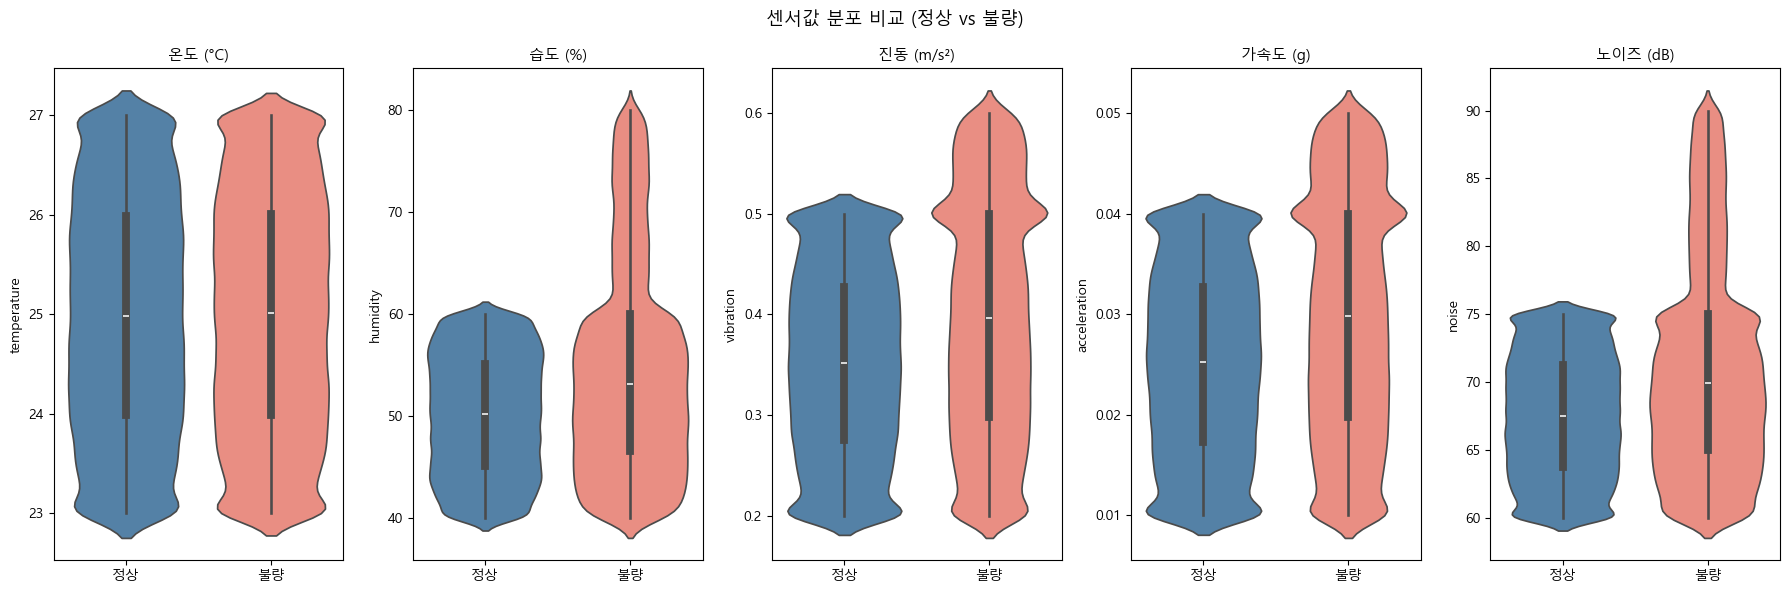

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

sensors = ["temperature", "humidity", "vibration", "acceleration", "noise"]
sensor_labels = {
    "temperature":  "온도 (°C)",
    "humidity":     "습도 (%)",
    "vibration":    "진동 (m/s²)",
    "acceleration": "가속도 (g)",
    "noise":        "노이즈 (dB)"
}

fig, axes = plt.subplots(1, len(sensors), figsize=(18, 6))

for ax, sensor in zip(axes, sensors):
    sns.violinplot(
        data=df,
        x="양불량",
        y=sensor,
        hue="양불량",         # 추가
        palette=["steelblue", "salmon"],
        inner="box",
        legend=False,         # 추가
        ax=ax
    )
    ax.set_title(sensor_labels[sensor], fontsize=11)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["정상", "불량"])

fig.suptitle("센서값 분포 비교 (정상 vs 불량)", fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig("violin_plot.png", dpi=150, bbox_inches='tight')

* 온도를 제외한 모든 데이터들이 불량값들은 정상 범위의 상한을 뚫고 값들이 분포함을 알 수 있음.

### 로지스틱 회귀

In [10]:
df.head()

,timestamp,temperature,humidity,vibration,acceleration,noise,양불량
0,2025-08-07 09:01:04,23.20,40.47,0.4118,0.0178,81.82,1
1,2025-08-07 09:01:05,23.37,40.31,0.3872,0.0185,81.24,1
2,2025-08-07 09:01:06,23.59,40.01,0.3663,0.0209,80.71,1
3,2025-08-07 09:01:07,23.74,40.00,0.3512,0.0232,79.42,1
4,2025-08-07 09:01:08,23.97,40.00,0.3304,0.0251,78.51,1


In [11]:
import statsmodels.api as sm

X = df.drop(columns=["timestamp", "양불량"], axis=1)
y = df["양불량"]
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.492542
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    양불량   No. Observations:               205425
Model:                          Logit   Df Residuals:                   205419
Method:                           MLE   Df Model:                            5
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.2520
Time:                        22:37:07   Log-Likelihood:            -1.0118e+05
converged:                       True   LL-Null:                   -1.3526e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -19.9425      0.153   -129.958      0.000     -20.243     -19.642
temperature      0.0132      0.005      2.865      0.004       0.004       0.022
humidity         0.1061      0.001    147.704      0.000       0.105       0.107
vibration        7.2626      0.054    134.715      0.000       7.157       7.368
acceleration    73.9257      0.539    137.221      0.000      72.870      74.982
noise            0.1420      0.001    150.328      0.000       0.140       0.144
================================================================================
"""

* 모델의 R square 값이 0.1783이라고 좋다고는 할 수 없음.
* 뒤에 다른 방법 사용

## 파일 단위 집계
ex) json 파일 1개 = 1행

센서별로 mean/std/min/max/range 5가지 통계를 집계

In [8]:
DATA_ROOTS = [
    "../data/Training",
    "../data/Validation"
]

records = []

for DATA_ROOT in DATA_ROOTS:
    for json_file in Path(DATA_ROOT).rglob("*.json"):
        folder_name = json_file.parent.name
        if "불량" in folder_name:
            label = 1
        elif "정상" in folder_name:
            label = 0
        else:
            continue

        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        for sensor_block in data.get("sensor_data", []):
            seq = sensor_block.get("sensor_sequence", [])
            if not seq:
                continue

            df_seq = pd.DataFrame(seq)

            record = {
                "file_name": json_file.name,
                "folder":    folder_name,
            }

            for sensor in ["temperature", "humidity", "vibration", "acceleration", "noise"]:
                record[f"{sensor}_mean"] = df_seq[sensor].mean()
                record[f"{sensor}_std"]  = df_seq[sensor].std()

            record["양불량"] = label
            records.append(record)

df_file = pd.DataFrame(records)

print(df_file.shape)
print(df_file["양불량"].value_counts())

(46220, 13)
양불량
1    29162
0    17058
Name: count, dtype: int64


In [9]:
import statsmodels.api as sm

# 피처 선택
feature_cols = [col for col in df_file.columns 
                if col.endswith("_mean") or col.endswith("_std")]

X = df_file[feature_cols]
y = df_file["양불량"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.473045
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                    양불량   No. Observations:                46220
Model:                          Logit   Df Residuals:                    46209
Method:                           MLE   Df Model:                           10
Date:                Mon, 22 Jun 2026   Pseudo R-squ.:                  0.2816
Time:                        23:15:57   Log-Likelihood:                -21864.
converged:                       True   LL-Null:                       -30434.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -19.8909      0.339    -58.742      0.000     -20.555     -19.227
temperat

| 센서 | mean coef | std coef | 유의성 | 해석 |
|------|-----------|----------|--------|------|
| temperature | +0.006 | -0.005 | ❌ | 불량과 무관 |
| humidity | +0.113 | -0.250 | ✅ | 평균 높을수록 불량↑, 변동 클수록 불량↓ |
| vibration | +7.346 | -22.894 | ✅ | 평균 높을수록 불량↑, 변동 클수록 불량↓ |
| acceleration | +74.905 | -225.868 | ✅ | 영향력 가장 큼, vibration과 동일 패턴 |
| noise | +0.154 | -0.090 | ✅ | 평균 높을수록 불량↑, 변동 클수록 불량↓ |

#### Reference

1. 위 로지스틱 회귀 모델의 R2 값은 0.282로 우수하다
    - [McFadden, D. (1972). Conditional logit analysis of qualitative choice behavior.](https://escholarship.org/content/qt61s3q2xr/qt61s3q2xr.pdf)
    - McFadden 0.20~0.40을 "우수(excellent fit)"로 제시
2. 우리는 현재 공정 데이터를 사용하며 로지스틱 회귀 모델을 이진분류에 사용한다.
    - [Montgomery, D. C. (2020). Introduction to statistical quality control. John wiley & sons.](https://books.google.co.kr/books?hl=ko&lr=&id=oh7zDwAAQBAJ&oi=fnd&pg=PA2&dq=Montgomery,+D.C.+(2020).+Introduction+to+Statistical+Quality+Control+(8th+ed.).+Wiley.&ots=DsEua_Ka7y&sig=7gt3HPgP-5JrE4fj8G_FxhFqjF4&redir_esc=y#v=onepage&q=Montgomery%2C%20D.C.%20(2020).%20Introduction%20to%20Statistical%20Quality%20Control%20(8th%20ed.).%20Wiley.&f=false)
    - 공정 센서 데이터 기반 이진 불량 분류에 로지스틱 회귀가 널리 사용됨

---

#### 개선

In [10]:
# 파일 단위 불량률
total = len(df_file)
defect = df_file["양불량"].sum()
defect_rate = defect / total * 100

print(f"전체 파일 수: {total}")
print(f"불량 파일 수: {defect}")
print(f"정상 파일 수: {total - defect}")
print(f"현재 불량률: {defect_rate:.2f}%")

전체 파일 수: 46220
불량 파일 수: 29162
정상 파일 수: 17058
현재 불량률: 63.09%


* 실제 공정에서는 불량률이 이렇게 나오진않지만, 우리의 지금 상황에서의 목적은 불량률을 감소시키는 것이 주 목적
* 하단은 시뮬레이션 및 분석을 통한 우리의 방법론

    - 몬테카를로 시뮬레이션

        정상 데이터의 센서 분포를 기반으로 가상 공정 데이터를 대량 생성하고, 특정 센서 값을 변화시키면서 예측 불량률이 어떻게 바뀌는지 시뮬레이션

    - 민감도 분석

        센서 하나씩 값을 구간별로 변화시키면서 불량 확률 변화를 곡선으로 그림

        "진동이 얼마를 넘으면 불량 확률이 50%를 초과하는가" 같은 임계값 도출 가능

③ 민감도 분석 (진동·가속도)
vibration_mean: 0.2000 ~ 0.6000
acceleration_mean: 0.0100 ~ 0.0500
진동 평균 (m/s²) 임계값: 0.4101
가속도 평균 (g) 임계값: 0.0306


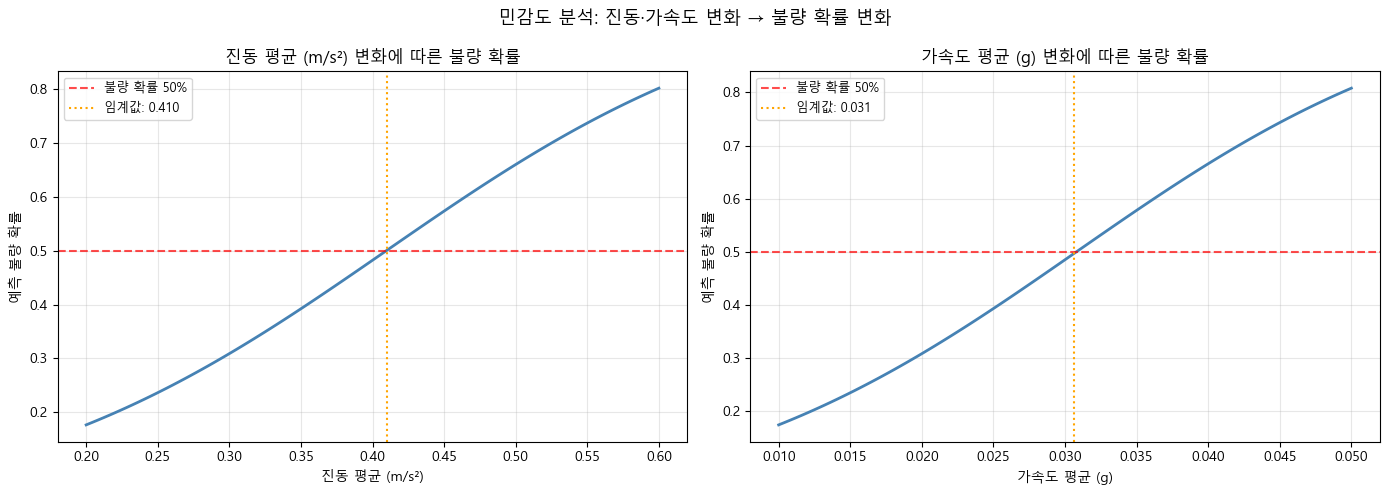


② 몬테카를로 시뮬레이션 (임계값 적용)
현재 실제 불량률:          63.09%
현재 모델 예측 불량률:     68.27%
임계값 적용 후 불량률:     35.20%
예측 불량률 감소:          33.07%p


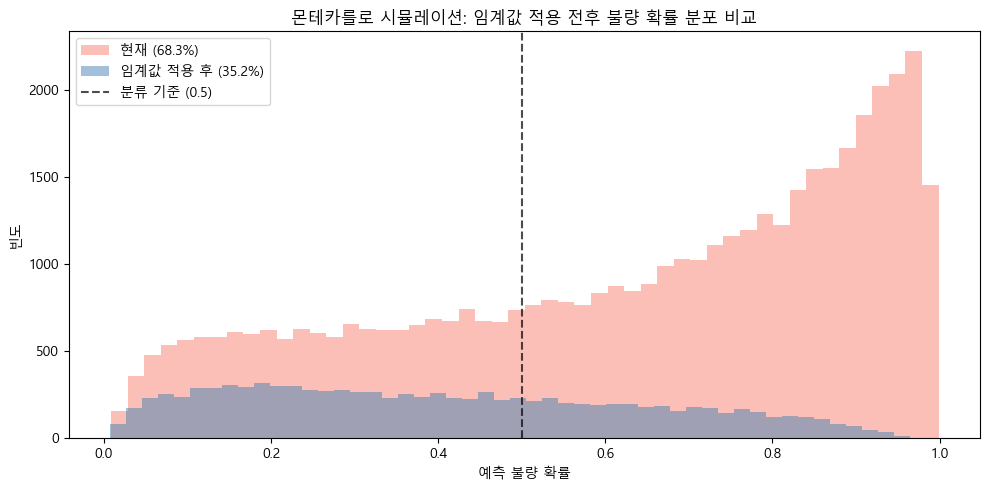

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# ============================================================
# 정상 데이터 분포 추출
# ============================================================
df_normal = df_file[df_file["양불량"] == 0]

sensor_stats = {}
for sensor in ["humidity", "vibration", "acceleration", "noise"]:
    sensor_stats[sensor] = {
        "mean": df_normal[f"{sensor}_mean"].mean(),
        "std":  df_normal[f"{sensor}_mean"].std()
    }

# ============================================================
# 민감도 분석으로 도출한 임계값
# ============================================================
thresholds = {
    "vibration_mean":    0.410,
    "acceleration_mean": 0.031,
}

# ============================================================
# ③ 민감도 분석 (진동, 가속도만)
# ============================================================
print("=" * 50)
print("③ 민감도 분석 (진동·가속도)")
print("=" * 50)

base = {col: df_file[df_file["양불량"]==0][col].mean() for col in df_sim.columns}

target_sensors = {}
for sensor in ["vibration_mean", "acceleration_mean"]:
    min_val = df_file[sensor].min()
    max_val = df_file[sensor].max()
    target_sensors[sensor] = np.linspace(min_val, max_val, 100)
    print(f"{sensor}: {min_val:.4f} ~ {max_val:.4f}")

sensor_kor = {
    "vibration_mean":    "진동 평균 (m/s²)",
    "acceleration_mean": "가속도 평균 (g)",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sensor, values) in zip(axes, target_sensors.items()):
    probs = []
    for v in values:
        row = base.copy()
        row[sensor] = v
        X_row = pd.DataFrame([row])
        X_row = sm.add_constant(X_row, has_constant='add')
        X_row = X_row[result.params.index]
        probs.append(result.predict(X_row)[0])

    ax.plot(values, probs, color="steelblue", linewidth=2)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.7, label="불량 확률 50%")

    threshold_idx = np.argmin(np.abs(np.array(probs) - 0.5))
    thresholds[sensor] = values[threshold_idx]  # 임계값 자동 저장
    ax.axvline(thresholds[sensor], color="orange", linestyle=":",
               label=f"임계값: {thresholds[sensor]:.3f}")

    ax.set_xlabel(sensor_kor[sensor])
    ax.set_ylabel("예측 불량 확률")
    ax.set_title(f"{sensor_kor[sensor]} 변화에 따른 불량 확률")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    print(f"{sensor_kor[sensor]} 임계값: {thresholds[sensor]:.4f}")

plt.suptitle("민감도 분석: 진동·가속도 변화 → 불량 확률 변화", fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig("sensitivity.png", dpi=150, bbox_inches='tight')

# ============================================================
# ② 몬테카를로 시뮬레이션 (임계값 클리핑 후 샘플링)
# ============================================================
print("\n" + "=" * 50)
print("② 몬테카를로 시뮬레이션 (임계값 적용)")
print("=" * 50)

N = 10000
np.random.seed(42)

# 임계값 클리핑 적용
df_clipped = df_file.copy()
for sensor, threshold in thresholds.items():
    df_clipped[sensor] = df_clipped[sensor].clip(upper=threshold)

# 클리핑된 분포에서 샘플링
# 진동/가속도만 클리핑, 나머지는 정상 데이터에서만 샘플링
sim_data = {}
for col in feature_cols:
    if col in thresholds:
        # 임계값 클리핑 적용된 전체 데이터에서 샘플링
        sim_data[col] = np.random.choice(df_clipped[col].values, size=N, replace=True)
    else:
        # 나머지는 정상 데이터에서만 샘플링
        sim_data[col] = np.random.choice(df_file[df_file["양불량"]==0][col].values, size=N, replace=True)

df_sim = pd.DataFrame(sim_data)
df_sim_const = sm.add_constant(df_sim, has_constant='add')
df_sim_const = df_sim_const[result.params.index]
sim_probs = result.predict(df_sim_const)

# 현재 예측 불량률
X_all = sm.add_constant(df_file[feature_cols], has_constant='add')
X_all = X_all[result.params.index]
all_probs = result.predict(X_all)
current_pred_defect_rate = (all_probs >= 0.5).mean() * 100
improved_pred_defect_rate = (sim_probs >= 0.5).mean() * 100

print(f"현재 실제 불량률:          {defect_rate:.2f}%")
print(f"현재 모델 예측 불량률:     {current_pred_defect_rate:.2f}%")
print(f"임계값 적용 후 불량률:     {improved_pred_defect_rate:.2f}%")
print(f"예측 불량률 감소:          {current_pred_defect_rate - improved_pred_defect_rate:.2f}%p")

# 히스토그램
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_probs, bins=50, color="salmon", alpha=0.5, label=f"현재 ({current_pred_defect_rate:.1f}%)")
ax.hist(sim_probs, bins=50, color="steelblue", alpha=0.5, label=f"임계값 적용 후 ({improved_pred_defect_rate:.1f}%)")
ax.axvline(0.5, color="black", linestyle="--", alpha=0.7, label="분류 기준 (0.5)")
ax.set_xlabel("예측 불량 확률")
ax.set_ylabel("빈도")
ax.set_title("몬테카를로 시뮬레이션: 임계값 적용 전후 불량 확률 분포 비교")
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("montecarlo.png", dpi=150, bbox_inches='tight')

| 센서 | 임계값 | 의미 |
|------|--------|------|
| 진동 | 0.410 m/s² | 진동이 0.410 이상이면 불량 확률 50% 초과 |
| 가속도 | 0.031 g | 가속도가 0.031 이상이면 불량 확률 50% 초과 |
| 습도 | 53.7 % | 습도가 53.7% 이상이면 불량 확률 50% 초과 |
| 노이즈 | 70.3 dB | 노이즈가 70.3dB 이상이면 불량 확률 50% 초과 |

* 실제 불량률과 로지스틱 모델로 학습하고 예측 한 불량률은 63.10과 68.27로 그렇게 차이나지 않음을 알 수 있음.
* 개선 후 데이터는 없기때문에 모델로 돌려 불량률이 내려가는지 확인

---

1. 서론
    - 연구배경
    - 공정 설명
    - 사용 데이터
        - 선정 이유
        - EDA
    - 방법론 설명
        - 로지스틱
        - 민감도
        - 몬테카를로
    

2. 결론
    - 결과 (로지스틱, ...)
    - 한계
        + 우리가 공장이 없다, 그래서 시뮬레이션밖에 못 했다
        + GPT chance

Reference